# Финальный проект в сфере E-com в рамках специализации Яндекс Лицея 2026

## Импорты


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import kruskal, spearmanr, mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

## Исследовательский анализ данных и предобработка

Загрузка и просмотр данных на правильную кодировку


In [2]:
ecom_df = pd.read_csv("ecom_yl_new.csv", sep=";", decimal=".")

ecom_df.head()

,User Id,Region,Device,Channel,Session Start,Session End,SessionDurationSec,Session Date,Month,Day,Hour of day,Order Dt,Revenue,Payment Type,Promo code
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0,2025-05-01,5,3,0,2025-05-01 00:06:40,9999.0,Mobile payments,0.0
1,601292388085,United States,PC,organic,2025-05-01 06:56:16,2025-05-01 07:09:18,782.0,2025-05-01,5,3,7,NaN,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.0,2025-05-01,5,3,4,NaN,NaN,NaN,NaN
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.0,2025-05-01,5,3,18,NaN,NaN,NaN,NaN
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.0,2025-05-02,5,4,14,NaN,NaN,NaN,NaN


### Названия столбцов в соответствии с PEP8


In [3]:
# все с маленькой буквой и замена пробела на _
ecom_df.columns = ecom_df.columns.str.lower().str.replace(" ", "_")

ecom_df.columns.to_list()

['user_id',
 'region',
 'device',
 'channel',
 'session_start',
 'session_end',
 'sessiondurationsec',
 'session_date',
 'month',
 'day',
 'hour_of_day',
 'order_dt',
 'revenue',
 'payment_type',
 'promo_code']

### Проверка данных и работа с пропусками


In [4]:
ecom_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             1012 non-null   int64  
 1   region              999 non-null    str    
 2   device              999 non-null    str    
 3   channel             999 non-null    str    
 4   session_start       1012 non-null   str    
 5   session_end         1012 non-null   str    
 6   sessiondurationsec  1012 non-null   float64
 7   session_date        1012 non-null   str    
 8   month               1012 non-null   int64  
 9   day                 1012 non-null   int64  
 10  hour_of_day         1012 non-null   int64  
 11  order_dt            285 non-null    str    
 12  revenue             285 non-null    float64
 13  payment_type        285 non-null    str    
 14  promo_code          285 non-null    float64
dtypes: float64(3), int64(4), str(8)
memory usage: 212.1 KB


- Датафрейм содержит 1012 записей (строк) и 15 столбцов

**Целостность данных:**

- 8 столбцов не имеют пропусков: user_id, session_start, session_end, sessiondurationsec, session_date, month, day, hour_of_day
- 3 столбца с незначительными пропусками: region, device, channel 13 строк ~ (1%) — можно удалить или заполнить
- 4 столбца с большим количеством пропусков: order_dt, revenue, payment_type, promo_code
  727 пропусков ~ (72%)

Изучим каждый из столбцов подробнее

**Типизация:**

- Числовые признаки: user_id, month, day, hour_of_day, sessiondurationsec, revenue, promo_code

- Категориальные: region, device, channel, payment_type — требуют one-hot encoding

- Временные: session_start, session_end, session_date, order_dt

#### Столбцы с малым количеством пропусков (region, device, channel)

##### исследуем столбец region


In [5]:
ecom_df["region"].unique()

<ArrowStringArray>
['United States',        'Frаnce', 'Unjted States',       'Germany',
            'UK',        'France',        'Frаncе',        'Franсe',
       'germany',             nan,            'UК']
Length: 11, dtype: str

Видно, что некоторые регионы одинаковы, но написаны по разному.  
Можно выделить 4 региона: United States, UK, Germany, France.


Исследуем отсутствующие данные на важность


In [6]:
ecom_df["region"].value_counts()

region
United States    535
Unjted States    144
UK               111
Germany           89
France            52
Frаnce            32
germany           13
Frаncе            10
Franсe             9
UК                 4
Name: count, dtype: int64

In [7]:
ecom_df[ecom_df["region"].isna()]

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
303,434852403169,NaN,NaN,NaN,2025-07-01 07:36:39,2025-07-01 07:52:15,936.0,2025-07-01,7,1,7,2025-07-01 07:36:46,4999.0,Debit card,1.0
392,213468351687,NaN,NaN,NaN,2025-07-20 21:19:14,2025-07-20 21:32:09,775.0,2025-07-20,7,6,21,NaN,NaN,NaN,NaN
429,679176482300,NaN,NaN,NaN,2025-07-28 02:19:45,2025-07-28 03:04:59,2714.0,2025-07-28,7,7,3,NaN,NaN,NaN,NaN
547,87458247642,NaN,NaN,NaN,2025-08-16 17:33:09,2025-08-16 18:02:53,1784.0,2025-08-16,8,5,18,2025-08-16 17:33:25,4999.0,Credit card,0.0
549,588840798518,NaN,NaN,NaN,2025-08-16 16:46:22,2025-08-16 17:34:45,2903.0,2025-08-16,8,5,17,2025-08-16 16:47:07,4999.0,E-wallet,0.0
564,61219447121,NaN,NaN,NaN,2025-08-18 08:16:27,2025-08-18 08:28:59,752.0,2025-08-18,8,7,8,2025-08-18 08:16:33,4999.0,Cash,0.0
599,16254498222,NaN,NaN,NaN,2025-08-25 13:21:44,2025-08-25 13:43:23,1299.0,2025-08-25,8,7,13,2025-08-25 13:21:55,4999.0,Cash,1.0
600,16254498222,NaN,NaN,NaN,2025-08-25 13:21:44,2025-08-25 13:43:23,1299.0,2025-08-25,8,7,13,2025-08-25 13:21:55,4999.0,Cash,1.0
652,427486793654,NaN,NaN,NaN,2025-09-03 06:02:54,2025-09-03 07:00:02,3428.0,2025-09-03,9,2,7,2025-09-03 06:03:39,4999.0,Debit card,1.0
686,632186207840,NaN,NaN,NaN,2025-09-10 07:21:58,2025-09-10 07:45:43,1425.0,2025-09-10,9,2,7,NaN,NaN,NaN,NaN


В строках есть один явный дубликат.  
Вместе с регионом отсутствуют данне об устройствах и каналах

Пустые строки составляют 1% от данных. Также у этих строк отсутствует информация по рекламному каналу, что не позволит ответить на вопрос инвесторов об эффективности инвестиций. Учитывая малый процент данных они удаляются.

Учитывая одинаковую стоимость покупки, возможно, проблема периодически появляется на конкретный товар


In [8]:
# удаление пропусков
ecom_df = ecom_df.dropna(subset=["region"])

# проверка, что пропусков в регионе больше нет
print("Пропуски region -", ecom_df["region"].isna().sum(), "\n")

# проверка
ecom_df.info()

Пропуски region - 0 

<class 'pandas.DataFrame'>
Index: 999 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             999 non-null    int64  
 1   region              999 non-null    str    
 2   device              999 non-null    str    
 3   channel             999 non-null    str    
 4   session_start       999 non-null    str    
 5   session_end         999 non-null    str    
 6   sessiondurationsec  999 non-null    float64
 7   session_date        999 non-null    str    
 8   month               999 non-null    int64  
 9   day                 999 non-null    int64  
 10  hour_of_day         999 non-null    int64  
 11  order_dt            277 non-null    str    
 12  revenue             277 non-null    float64
 13  payment_type        277 non-null    str    
 14  promo_code          277 non-null    float64
dtypes: float64(3), int64(4), str(8)
memory usage: 217.

Видно, что с удалением пропусков ячеек region, были также удалены пропуски в столбцах: device, channel. Поэтому в исследовании на пропуски они больше не нуждаются.

#### Столбцы с большим количеством пропусков (order_dt, revenue, payment_type, promo_code)

Изучив данные, можно заметить, что пропуски в этих колонках соответствуют клиентам, которые ничего не покупали (что не является ошибкой данных). Соответственно, их заполнение не имеет смысла. Изучим только те строки, в которых эти элементы заполнены.

Всего строк 999, для каждого столбца заполнено 277 ячеек (722 пропуска). Но может быть такое, что заполнены разные комбинации ячеек, которые могут давать такую сумму (необходимо, чтобы все 4 элемента в одной строке были заполнены одновременно). Проверим такой вариант


In [9]:
# проверка что все 4 ячейки заполнены
has_any_null = (
    ecom_df[["order_dt", "revenue", "payment_type", "promo_code"]]
    .isna()
    .any(axis=1)
)

print(f"Строк с пропусками: {has_any_null.sum()}")

Строк с пропусками: 722


Для каждой строки клиента, который совершил покупку, все 4 столбца заполнены. Если бы хоть одна ячейка была не заполнена, то количество строк с пропусками было бы меньше 722.

Соответственно, столбцы order_dt, revenue, payment_type, promo_code не нуждаются в заполнении пропусков.

### Исследуем данные на дубликаты, в том числе на неявные дубликаты в категориальных данных

Напомню, что один дубликат был уже удален на этапе работы с пропусками столбца region


In [10]:
ecom_df[ecom_df.duplicated(keep=False)]

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
67,768710666,Unjted States,iPhone,реклама у блогеров,2025-05-17 18:24:36,2025-05-17 18:28:05,209.0,2025-05-17,5,5,18,2025-05-17 18:24:36,9999.0,Mobile payments,0.862715
68,768710666,Unjted States,iPhone,реклама у блогеров,2025-05-17 18:24:36,2025-05-17 18:28:05,209.0,2025-05-17,5,5,18,2025-05-17 18:24:36,9999.0,Mobile payments,0.862715
195,134214602428,Unjted States,Android,социальные сети,2025-06-11 02:35:48,2025-06-11 03:45:47,4199.0,2025-06-11,6,2,3,2025-06-11 02:35:48,4999.0,Mobile payments,1.000000
196,134214602428,Unjted States,Android,социальные сети,2025-06-11 02:35:48,2025-06-11 03:45:47,4199.0,2025-06-11,6,2,3,2025-06-11 02:35:48,4999.0,Mobile payments,1.000000


Обнаружены явные дубликаты. Такой ситуации быть не может — дубликаты удаляются

Все дубликаты (включая ранее удаленный) совершили покупку и использовали промокод, возможно, это связано с удобством применения промокода на этапе покупки


In [11]:
ecom_df = ecom_df.drop_duplicates()

print("количество дубликатов -", ecom_df.duplicated().sum(), "\n")

ecom_df.info()

количество дубликатов - 0 

<class 'pandas.DataFrame'>
Index: 997 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             997 non-null    int64  
 1   region              997 non-null    str    
 2   device              997 non-null    str    
 3   channel             997 non-null    str    
 4   session_start       997 non-null    str    
 5   session_end         997 non-null    str    
 6   sessiondurationsec  997 non-null    float64
 7   session_date        997 non-null    str    
 8   month               997 non-null    int64  
 9   day                 997 non-null    int64  
 10  hour_of_day         997 non-null    int64  
 11  order_dt            275 non-null    str    
 12  revenue             275 non-null    float64
 13  payment_type        275 non-null    str    
 14  promo_code          275 non-null    float64
dtypes: float64(3), int64(4), str(8)
memory usage

явнях дубликатов нет

#### Неявные дубликаты в категориальных данных

К таким относятся столбцы: region, device, channel, month, day, hour_of_day, payment_type, promo_code.  
Дополнительно каждую их этих колонок переведем в тип category

##### reqion


In [12]:
ecom_df["region"].unique()

<ArrowStringArray>
['United States',        'Frаnce', 'Unjted States',       'Germany',
            'UK',        'France',        'Frаncе',        'Franсe',
       'germany',            'UК']
Length: 10, dtype: str

Всего можно выделить 4 региона: United States, UK, Germany, France. Избавление от дубликатов


In [13]:
ecom_df["region"] = ecom_df["region"].replace(
    {
        "Unjted States": "United States",
        "United States": "United States",
        "UK": "UK",
        "UК": "UK",
        "Germany": "Germany",
        "germany": "Germany",
        "Frаnce": "France",
        "France": "France",
        "Frаncе": "France",
        "Franсe": "France",
    }
)

ecom_df["region"] = ecom_df["region"].astype("category")
ecom_df["region"].unique()

['United States', 'France', 'Germany', 'UK']
Categories (4, str): ['France', 'Germany', 'UK', 'United States']

дубликаты устранены

##### Колонака device


In [14]:
ecom_df["device"].unique()

<ArrowStringArray>
['iPhone', 'PC', 'Mac', 'Android', 'android']
Length: 5, dtype: str

Можно выделить 4 уникальных элемента: iPhone, PC, Mac, Android. Заменим android на Android


In [15]:
ecom_df["device"] = ecom_df["device"].replace("android", "Android")

ecom_df["device"] = ecom_df["device"].astype("category")
ecom_df["device"].unique()

['iPhone', 'PC', 'Mac', 'Android']
Categories (4, str): ['Android', 'Mac', 'PC', 'iPhone']

дубликаты устранены

##### Колонка channel

из условия есть 5 рекламных каналов

- органические пользователи (бесплатно)
- email-рассылки (дешево)
- реклама у блогеров (середина)
- контекстная реклама (дорого)
- социальные сети (дорого)


In [16]:
ecom_df["channel"].unique()

<ArrowStringArray>
[    'социальные сети',             'organic',  'реклама у блогеров',
  'контексная реклама',      'email-рассылки', 'контекстная реклама']
Length: 6, dtype: str

organic - органические пользователи
контексная реклама - опечатка

исправим неявные дубликаты


In [17]:
ecom_df["channel"] = ecom_df["channel"].replace(
    {
        "organic": "органические пользователи",
        "контексная реклама": "контекстная реклама",
    }
)

ecom_df["channel"] = ecom_df["channel"].astype("category")
ecom_df["channel"].unique()

['социальные сети', 'органические пользователи', 'реклама у блогеров', 'контекстная реклама', 'email-рассылки']
Categories (5, str): ['email-рассылки', 'контекстная реклама', 'органические пользователи', 'реклама у блогеров', 'социальные сети']

дубликаты устранены

##### Колонка month


In [18]:
ecom_df["month"].unique()

array([ 5,  6,  7,  8,  9, 10])

месяца написаны корректно с мая по октябрь. Проведем преобразование типа данных


In [19]:
ecom_df["month"] = ecom_df["month"].astype("category")

##### Колонка day


In [20]:
ecom_df["day"].unique()

array([3, 4, 5, 6, 7, 1, 2])

Дни недели правильные с 1 по 7. Проведем преобразование типа данных


In [21]:
ecom_df["day"] = ecom_df["day"].astype("category")

##### Колонка hour_of_day


In [22]:
ecom_df["hour_of_day"].sort_values().unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

Все часы написаны правильно от 0 до 23. Проведем преобразование типа данных


In [23]:
ecom_df["hour_of_day"] = ecom_df["hour_of_day"].astype("category")

##### Колонка payment_type


In [24]:
ecom_df["payment_type"].unique()

<ArrowStringArray>
['Mobile payments', nan, 'Debit card', 'E-wallet', 'Cash', 'Credit card']
Length: 6, dtype: str

Все 5 способов оплаты уникальны. Проведем преобразование типа данных


In [25]:
ecom_df["payment_type"] = ecom_df["payment_type"].astype("category")

##### Колонка promo_code


In [26]:
ecom_df["promo_code"].unique()

array([0.        ,        nan, 1.        , 0.86271506])

Изучим строки, у которых значение promo_code = 0.86271506


In [27]:
ecom_df[
    (ecom_df["promo_code"] != 0)
    & (ecom_df["promo_code"] != 1)
    & (ecom_df["promo_code"].notna())
]

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code
67,768710666,United States,iPhone,реклама у блогеров,2025-05-17 18:24:36,2025-05-17 18:28:05,209.0,2025-05-17,5,5,18,2025-05-17 18:24:36,9999.0,Mobile payments,0.862715
495,12480325582,United States,Mac,социальные сети,2025-08-10 06:26:44,2025-08-10 06:49:56,1392.0,2025-08-10,8,6,6,2025-08-10 06:26:44,4999.0,E-wallet,0.862715


Строки соответствуют продажам с использованием промокода. Заменю значение на 1, возможно использовалась формула для колонки promo_code. Если бы промокода не было, то значение принимало 0.


In [28]:
ecom_df.loc[
    (ecom_df["promo_code"] != 0)
    & (ecom_df["promo_code"] != 1)
    & (ecom_df["promo_code"].notna()),
    "promo_code",
] = 1


ecom_df["promo_code"] = (
    ecom_df["promo_code"].astype("Int64").astype("category")
)

ecom_df["promo_code"].unique()

[0, NaN, 1]
Categories (2, Int64): [0, 1]

Дубликаты устранены

#### Неявные дубликаты (без учета id пользователей)


In [29]:
# проверим, что не учитывается id колонка
col_without_id = ecom_df.columns.tolist()[1:]
print(col_without_id)

ecom_df[ecom_df[ecom_df.columns.tolist()[1:]].duplicated(keep=False)]

['region', 'device', 'channel', 'session_start', 'session_end', 'sessiondurationsec', 'session_date', 'month', 'day', 'hour_of_day', 'order_dt', 'revenue', 'payment_type', 'promo_code']


,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code


Неявных дубликатов нет. Отдально смотреть id на дубликаты не надо, данные описывают продажи а не пользователей

### Перевод столбцов на тип данных с датой и временем

Такие столбцы: Session Start, Session End, Session Date, Order Dt. Переведем их в формат pd.to_datetime()

Столбцы month, day, hour_of_day представлены в виде чисел, поэтому ранее их преобразовал в категориальный тип данных


In [30]:
ecom_df["session_start"] = pd.to_datetime(ecom_df["session_start"])
ecom_df["session_end"] = pd.to_datetime(ecom_df["session_end"])
ecom_df["session_date"] = pd.to_datetime(ecom_df["session_date"])
ecom_df["order_dt"] = pd.to_datetime(ecom_df["order_dt"])

ecom_df.info()

<class 'pandas.DataFrame'>
Index: 997 entries, 0 to 1011
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_id             997 non-null    int64         
 1   region              997 non-null    category      
 2   device              997 non-null    category      
 3   channel             997 non-null    category      
 4   session_start       997 non-null    datetime64[us]
 5   session_end         997 non-null    datetime64[us]
 6   sessiondurationsec  997 non-null    float64       
 7   session_date        997 non-null    datetime64[us]
 8   month               997 non-null    category      
 9   day                 997 non-null    category      
 10  hour_of_day         997 non-null    category      
 11  order_dt            275 non-null    datetime64[us]
 12  revenue             275 non-null    float64       
 13  payment_type        275 non-null    category      
 14  promo_cod

### Столбец с итоговой суммой покупки с учетом применения промокода на скидку 10%

навзание столбца - total_amount


In [31]:
# создание столбца total_amount и вычисление чека с учетом промокода 10%
ecom_df["total_amount"] = ecom_df["revenue"] * (
    1 - (ecom_df["promo_code"].astype(float) * 0.1)
)

ecom_df[ecom_df["total_amount"].notna()].head()

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_amount
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0,2025-05-01,5,3,0,2025-05-01 00:06:40,9999.0,Mobile payments,0,9999.0
20,771147371911,United States,Android,органические пользователи,2025-05-06 15:49:16,2025-05-06 15:53:16,240.0,2025-05-06,5,1,15,2025-05-06 15:49:16,4999.0,Mobile payments,0,4999.0
28,245941309860,Germany,Mac,органические пользователи,2025-05-07 12:00:49,2025-05-07 13:10:26,4177.0,2025-05-07,5,2,13,2025-05-07 12:01:43,4999.0,Mobile payments,1,4499.1
33,25672200561,United States,Android,органические пользователи,2025-05-09 16:40:44,2025-05-09 16:41:31,47.0,2025-05-09,5,4,16,2025-05-09 16:40:44,4999.0,Debit card,1,4499.1
34,241867611399,United States,PC,социальные сети,2025-05-09 09:23:22,2025-05-09 09:28:28,306.0,2025-05-09,5,4,9,2025-05-09 09:23:24,4999.0,Mobile payments,0,4999.0


### Определение исследуемого периода

Чтобы ответить на этот вопрос, исследуем данные на дни без сессий (дата визита)


In [32]:
print(f"Дата первой сессии: {ecom_df['session_date'].min()}")
print(f"Дата последней сессии: {ecom_df['session_date'].max()}", "\n")

print(f"Дата первой покупки: {ecom_df['order_dt'].min()}")
print(f"Дата последней покупки: {ecom_df['order_dt'].max()}")

Дата первой сессии: 2025-05-01 00:00:00
Дата последней сессии: 2025-10-31 00:00:00 

Дата первой покупки: 2025-05-01 00:06:40
Дата последней покупки: 2025-10-31 16:05:38


Первая сессия и первая покупка произошли в один день. Последняя сессия и последняя покупка также произошли в один день
исследуем дни подробнее на наличие временного окна


всего уникальных дней 183 

session_date
2025-10-29     1
2025-06-04     1
2025-07-19     1
2025-07-20     1
2025-08-04     1
              ..
2025-10-13    11
2025-09-30    12
2025-10-05    12
2025-08-11    13
2025-10-27    13
Length: 183, dtype: int64


<Axes: title={'center': 'Активность по дням'}, xlabel='session_date'>

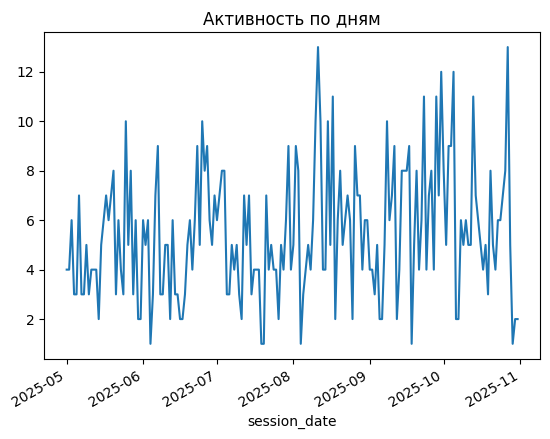

In [33]:
# количество уникальных календарных дней
print("всего уникальных дней", ecom_df["session_date"].dt.date.nunique(), "\n")

# количество повторений даты
daily_sessions = ecom_df.groupby("session_date").size()
print(daily_sessions.sort_values())

daily_sessions.plot(kind="line", title="Активность по дням")

Все дни, которые представлены, содержат минимум одно посещение. Всего дней с 1 мая по 31 октября - 184. Программа вывела - 183, значит явных временных окон нет.

Помимо этого, график показывает, что количество активных сессий (посещений сайта) пользователей растет.

Все месяцы представлены полностью или почти полностью.  
Исследуемый период — 6 месяцев (1 мая по 31 октябрь 2025 года). Используется весь период для анализа

### Проверка данных на выбросы и адекватность данных

К числовым столбцам относятся: SessionDurationSec, Revenue, total_amount (Revenue + promo_code)

Для удобства создадим функцию, которая строит гистограмму и boxplot, а также выводит основные метрики.


In [34]:
def plot_distribution(df, column, title, label):
    """Строит гистограмму и boxplot для указанного столбца и выводит метрики"""

    print(ecom_df[column].describe())

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Гистограмма
    sns.histplot(df, x=column, ax=axes[0])
    axes[0].set_title(f'Распределение "{title}"')
    axes[0].set_xlabel(label)
    axes[0].set_ylabel("Частота")

    # Boxplot
    sns.boxplot(df, x=column, ax=axes[1])
    axes[1].set_title(f'Выбросы "{title}"')
    axes[1].set_xlabel(label)

    plt.show()

    # Квартили и границы
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[df[column] > upper_bound]

    print(f"Верхняя граница: {upper_bound:.2f}")
    print(
        f"Количество выбросов: {len(outliers)},"
        f"({len(outliers)/len(df)*100:.2f}%)"
    )

In [35]:
ecom_df.head(3)

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_amount
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0,2025-05-01,5,3,0,2025-05-01 00:06:40,9999.0,Mobile payments,0,9999.0
1,601292388085,United States,PC,органические пользователи,2025-05-01 06:56:16,2025-05-01 07:09:18,782.0,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,NaN
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.0,2025-05-01,5,3,4,NaT,NaN,NaN,NaN,NaN


#### Колонка sessiondurationsec


count      997.000000
mean      1818.190572
std       1842.297223
min          0.000000
25%        531.000000
50%       1225.000000
75%       2510.000000
max      12388.000000
Name: sessiondurationsec, dtype: float64


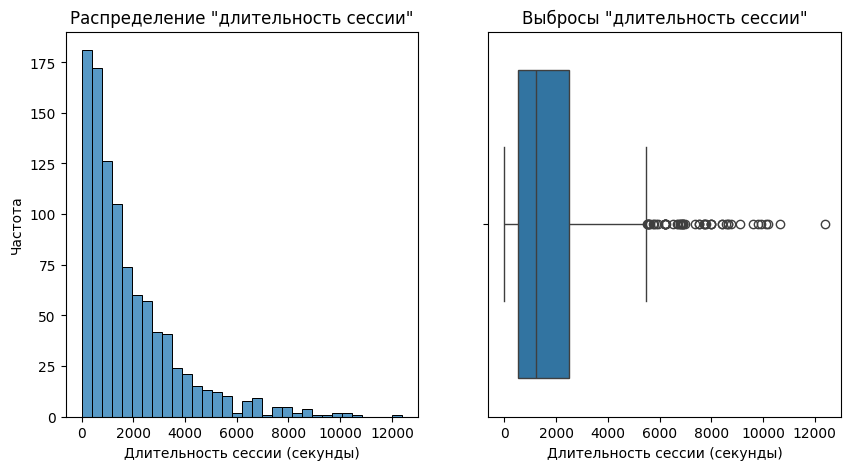

Верхняя граница: 5478.50
Количество выбросов: 52,(5.22%)


In [36]:
plot_distribution(
    df=ecom_df,
    column="sessiondurationsec",
    title="длительность сессии",
    label="Длительность сессии (секунды)",
)

Самое большое значение (и выброс) 12388 секунд или 3.4 часа. Такое возможно, но случай один и повлияет на дальнейший анализ. Замена максимум на предыдущее по максимуму число, потому что такие значений уже сконцентрированы и более правдоподобны


count      997.00000
mean      1816.45336
std       1833.11403
min          0.00000
25%        531.00000
50%       1225.00000
75%       2510.00000
max      10656.00000
Name: sessiondurationsec, dtype: float64


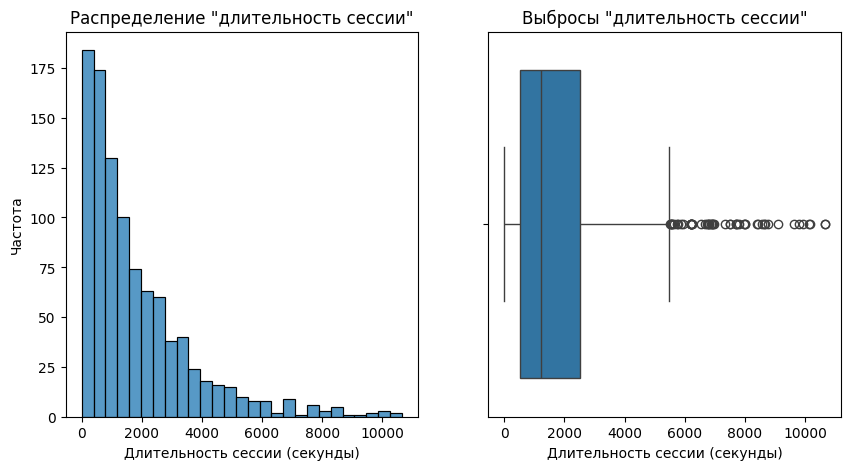

Верхняя граница: 5478.50
Количество выбросов: 52,(5.22%)


In [37]:
# максимальные число секунд
max_value_session = ecom_df["sessiondurationsec"].max()

# второе максимальное число
second_max_session = ecom_df[
    ecom_df["sessiondurationsec"] != max_value_session
]["sessiondurationsec"].max()

# замена
ecom_df["sessiondurationsec"] = ecom_df["sessiondurationsec"].replace(
    max_value_session, second_max_session
)

plot_distribution(
    df=ecom_df,
    column="sessiondurationsec",
    title="длительность сессии",
    label="Длительность сессии (секунды)",
)

Для колонки sessiondurationsec убран один выброс

#### Колонка Revenue


count       275.000000
mean       6911.756364
std       11408.249490
min           1.000000
25%        4999.000000
50%        4999.000000
75%        5999.000000
max      100000.000000
Name: revenue, dtype: float64


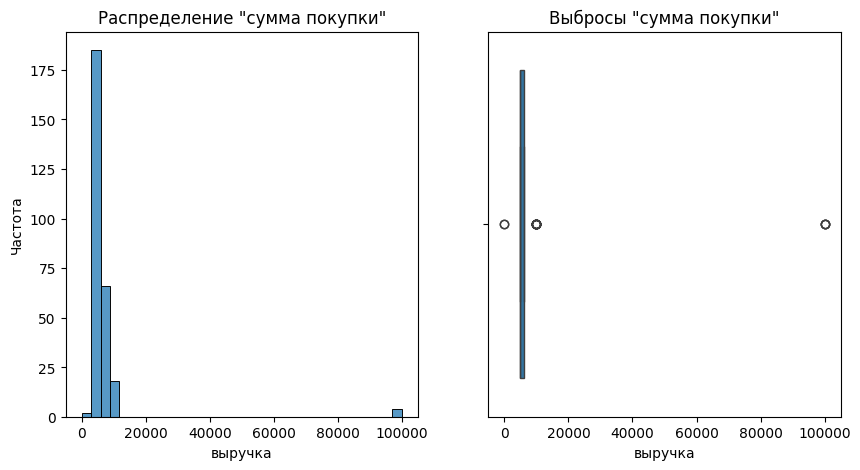

Верхняя граница: 7499.00
Количество выбросов: 22,(2.21%)


In [38]:
plot_distribution(
    df=ecom_df, column="revenue", title="сумма покупки", label="выручка"
)

Минимальное значение 1, максимальное 100 000.

Значение 100 000 может быть получено, но нам не дано количество купленных товаров, также близких к этому числу нет, поэтому принято решение поменять его на медиану.  
Значение с 1, больше похоже на ошибку или исключительных клиентов (их количество также небольшое), поэтому также считаю выбросом

Выброс 1 и 100 000 т. к. цены на товары распределены больше дискретно. Видно что чек 5 и 6 тыс. (25%, 50%, 75%), поэтому замена выбросов на медиану.


Количество значение меньше минимального чека 2
Количество значение чеков с единицей 2
count     275.000000
mean     5566.272727
std      1249.095227
min      4999.000000
25%      4999.000000
50%      4999.000000
75%      5999.000000
max      9999.000000
Name: revenue, dtype: float64


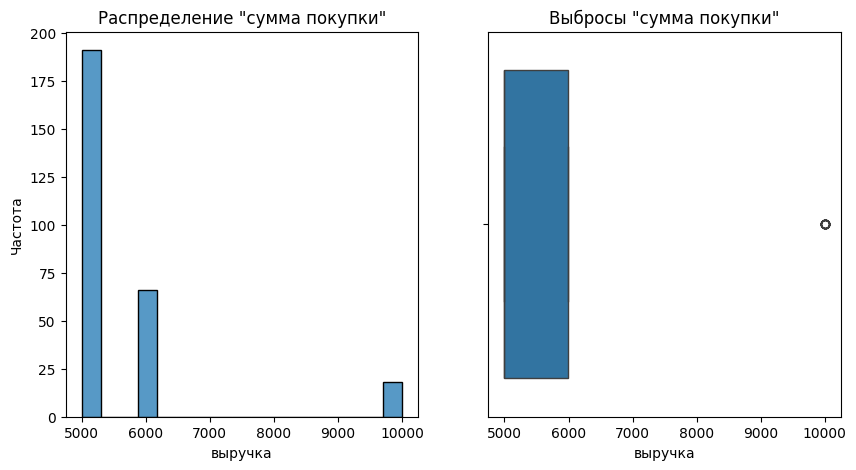

Верхняя граница: 7499.00
Количество выбросов: 18,(1.81%)


In [39]:
# проверка, что единственное число меньше минимального чека это 1
print(
    "Количество значение меньше минимального чека",
    len(ecom_df[ecom_df["revenue"] < 4999]),
)
print(
    "Количество значение чеков с единицей",
    len(ecom_df[ecom_df["revenue"] == 1]),
)

# избавление от выбросов
median_revenue = ecom_df[
    (ecom_df["revenue"] > 1) & (ecom_df["revenue"] < 100000)
]["revenue"].median()
ecom_df["revenue"] = ecom_df["revenue"].replace([1, 100000], median_revenue)

plot_distribution(
    df=ecom_df, column="revenue", title="сумма покупки", label="выручка"
)

Значений меньше минимального чека столько же сколько и чеков на 1. Поэтому ошибок в замене нет
Значение 9999 можно получить при покупке двух товаров за 4999, поэтому не считаю выбросом

#### Колонка total_amount


count       275.000000
mean       6714.693818
std       11138.384694
min           1.000000
25%        4999.000000
50%        4999.000000
75%        5999.000000
max      100000.000000
Name: total_amount, dtype: float64


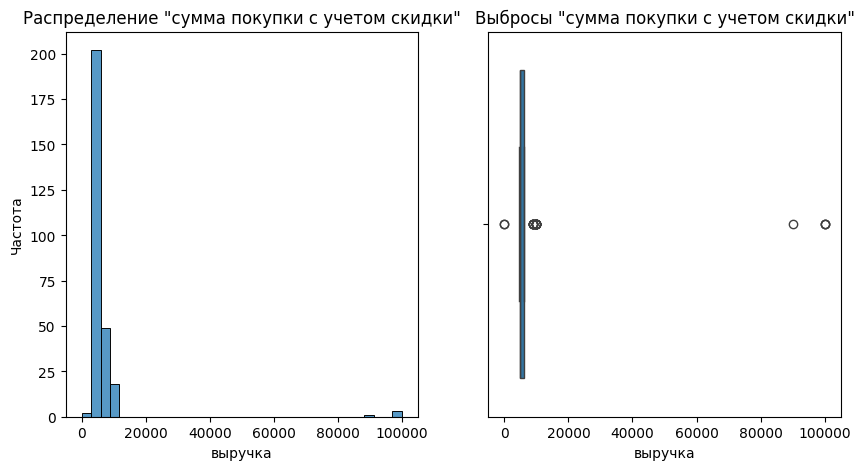

Верхняя граница: 7499.00
Количество выбросов: 22,(2.21%)


In [40]:
plot_distribution(
    df=ecom_df,
    column="total_amount",
    title="сумма покупки с учетом скидки",
    label="выручка",
)

Столбец произошел от revenue, поэтому логика работы с выбросами такая же. Замена выбросов (близких к 1 и 10000) на медиану, учитывая их группу (со скидкой или без скидки)


Все выбросы без скидки, поэтому заменим на медиану значений без скидки


count     275.000000
mean     5089.210545
std       486.973472
min      4499.100000
25%      4999.000000
50%      4999.000000
75%      4999.000000
max      5999.000000
Name: total_amount, dtype: float64


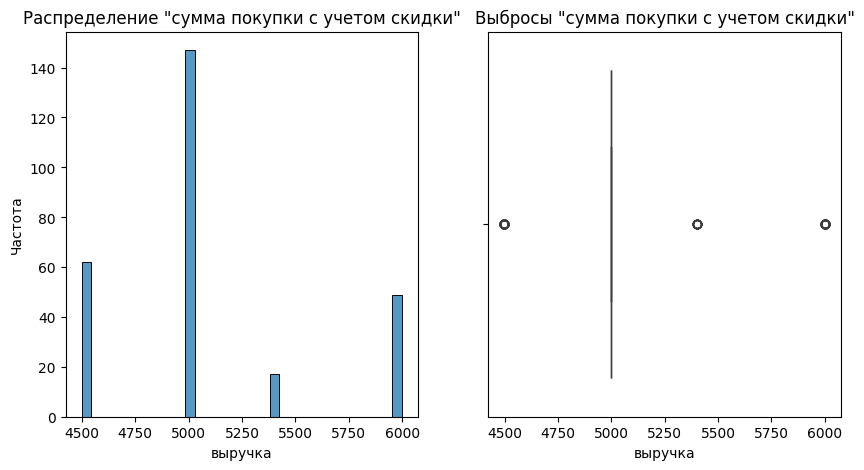

Верхняя граница: 4999.00
Количество выбросов: 66,(6.62%)


In [41]:
# вычисление квантилей и определение границ выбросов
q1, q3 = ecom_df["total_amount"].quantile([0.25, 0.75])

IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

# получение группы значений без выбросов (для правильного вычисления медианы)
mask_normal = (ecom_df["total_amount"] >= lower_bound) & (
    ecom_df["total_amount"] <= upper_bound
)

# вычисление медиан для групп с промокодом и без
median_by_promo = (
    ecom_df[mask_normal].groupby("promo_code")["total_amount"].median()
)
median_promo_0 = median_by_promo[0]
median_promo_1 = median_by_promo[1]

# выбросы
mask_outlier = (ecom_df["total_amount"] < lower_bound) | (
    ecom_df["total_amount"] > upper_bound
)

# замена выбросов
ecom_df.loc[mask_outlier & (ecom_df["promo_code"] == 0), "total_amount"] = (
    median_promo_0
)
ecom_df.loc[mask_outlier & (ecom_df["promo_code"] == 1), "total_amount"] = (
    median_promo_1
)

# вывод результата
plot_distribution(
    df=ecom_df,
    column="total_amount",
    title="сумма покупки с учетом скидки",
    label="выручка",
)

Выбросы в столбце total_amount заменены на медианные значения

### Столбец с указанием времени суток визита

- утро 06:00-09:59
- день 10:00-16:59
- вечер 17:00-21:59
- ночь 22:00-05:59

За время визита отвечает столбце time_of_day


In [42]:
def get_time_of_day(hour):
    """Определяет время суток по часу (0-23)"""
    if 6 <= hour <= 9:
        return "утро"

    if 10 <= hour <= 16:
        return "день"

    if 17 <= hour <= 21:
        return "вечер"

    return "ночь"


# создание столбца time_of_day и преобразование в категориальный тип данных
ecom_df["time_of_day"] = (
    ecom_df["hour_of_day"].apply(get_time_of_day).astype("category")
)

ecom_df.head()

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_amount,time_of_day
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0,2025-05-01,5,3,0,2025-05-01 00:06:40,9999.0,Mobile payments,0,4999.0,ночь
1,601292388085,United States,PC,органические пользователи,2025-05-01 06:56:16,2025-05-01 07:09:18,782.0,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,NaN,утро
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.0,2025-05-01,5,3,4,NaT,NaN,NaN,NaN,NaN,ночь
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.0,2025-05-01,5,3,18,NaT,NaN,NaN,NaN,NaN,вечер
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.0,2025-05-02,5,4,14,NaT,NaN,NaN,NaN,NaN,день


### Столбец “payer” с информацией о том, является ли пользователь платящим или нет.

За оплату товара буду брать столбец revenue. Если значение не пустое — пользователь платящий, если пустое (NaN) — не платящий.


In [43]:
# создание столбца payer и преобразование в категориальный тип данных
ecom_df["payer"] = ecom_df["revenue"].notna().astype("int").astype("category")
ecom_df.head()

,user_id,region,device,channel,session_start,session_end,sessiondurationsec,session_date,month,day,hour_of_day,order_dt,revenue,payment_type,promo_code,total_amount,time_of_day,payer
0,529697267522,United States,iPhone,социальные сети,2025-05-01 00:06:40,2025-05-01 00:07:06,26.0,2025-05-01,5,3,0,2025-05-01 00:06:40,9999.0,Mobile payments,0,4999.0,ночь,1
1,601292388085,United States,PC,органические пользователи,2025-05-01 06:56:16,2025-05-01 07:09:18,782.0,2025-05-01,5,3,7,NaT,NaN,NaN,NaN,NaN,утро,0
2,852898876338,United States,Mac,социальные сети,2025-05-01 04:30:45,2025-05-01 04:34:56,251.0,2025-05-01,5,3,4,NaT,NaN,NaN,NaN,NaN,ночь,0
3,998513020664,United States,iPhone,социальные сети,2025-05-01 18:53:42,2025-05-01 18:57:35,233.0,2025-05-01,5,3,18,NaT,NaN,NaN,NaN,NaN,вечер,0
4,240702200943,United States,Mac,социальные сети,2025-05-02 14:04:32,2025-05-02 14:09:51,319.0,2025-05-02,5,4,14,NaT,NaN,NaN,NaN,NaN,день,0


### Аналитический и графический анализ данных

Для удобства создам функцию построения круговой диаграммы


In [44]:
def plot_pie(data, title):
    plt.pie(
        data,
        labels=data.index,
        autopct="%1.1f%%",
        wedgeprops={"edgecolor": "white", "linewidth": 1},
    )

    plt.title(title)
    plt.show()


def plot_grouped_bar(value_cols_dict, title="", xlabel="", ylabel=""):
    """
    Построение группированной столбчатой диаграммы.
    value_cols_dict - словарь вида {'название': Series} для столбцов
    title, xlabel, ylabel - подписи
    """

    data = pd.DataFrame(value_cols_dict).fillna(0)

    # Сортировка по сумме столбцов (по убыванию)
    data["total"] = data.sum(axis=1)
    data = data.sort_values("total", ascending=False)
    data = data.drop("total", axis=1)

    ax = data.plot(kind="bar", figsize=(10, 6), edgecolor="white", linewidth=1)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(title="Статус", loc="upper right")
    plt.xticks(rotation=0)

    # Добавление цифр на столбцы
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

    plt.tight_layout()
    plt.show()

#### Доля продаж по регионам


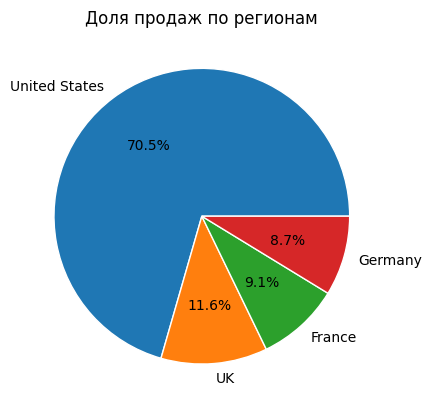

In [45]:
sales_region = ecom_df[ecom_df["payer"] == 1]["region"].value_counts()
plot_pie(sales_region, "Доля продаж по регионам")

Больше продаж приходится на United States (70%). Остальные регионы имеют примерно одинаковую долю продаж: UK (11.6%), France (9.5%), Germany (8.7%).
Проценты сверху - доля от общего числа

#### Доля продаж по источникам


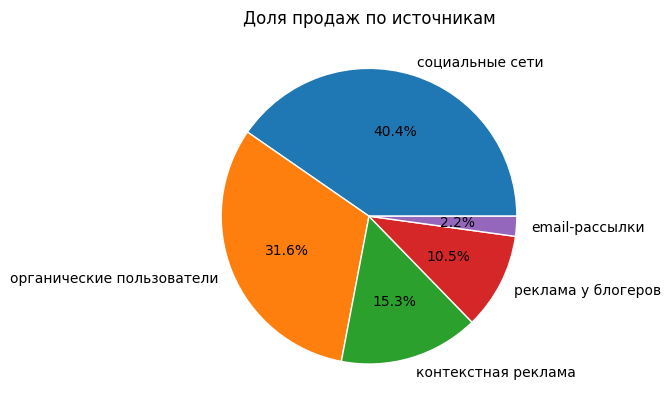

In [46]:
sales_channel = ecom_df[ecom_df["payer"] == 1]["channel"].value_counts()
plot_pie(sales_channel, "Доля продаж по источникам")

Больше всего покупателей пришли из социальных сетей (40.4%) и органических пользователей (31.6%). Контекстная реклама дала 15.3%, реклама у блогеров — 10.5%, email-рассылки — 2.2%.

#### Доля продаж по устройствам


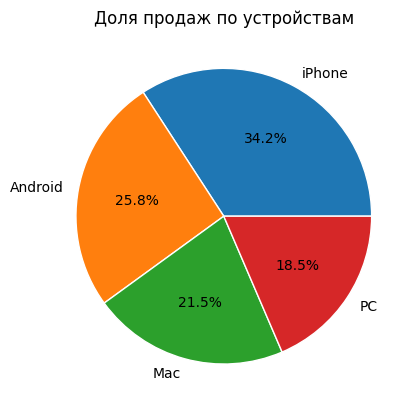

In [47]:
sales_device = ecom_df[ecom_df["payer"] == 1]["device"].value_counts()
plot_pie(sales_device, "Доля продаж по устройствам")

Мобильные устройства составляют 60% продаж (iPhone 34.2%, Android 25.8%), компьютеры — 40% (Mac 21.5%, PC 18.5%).  
Приоритет развития — мобильная платформа.

#### Количество пользователей с разбивкой на платящих/не платящих по регионам


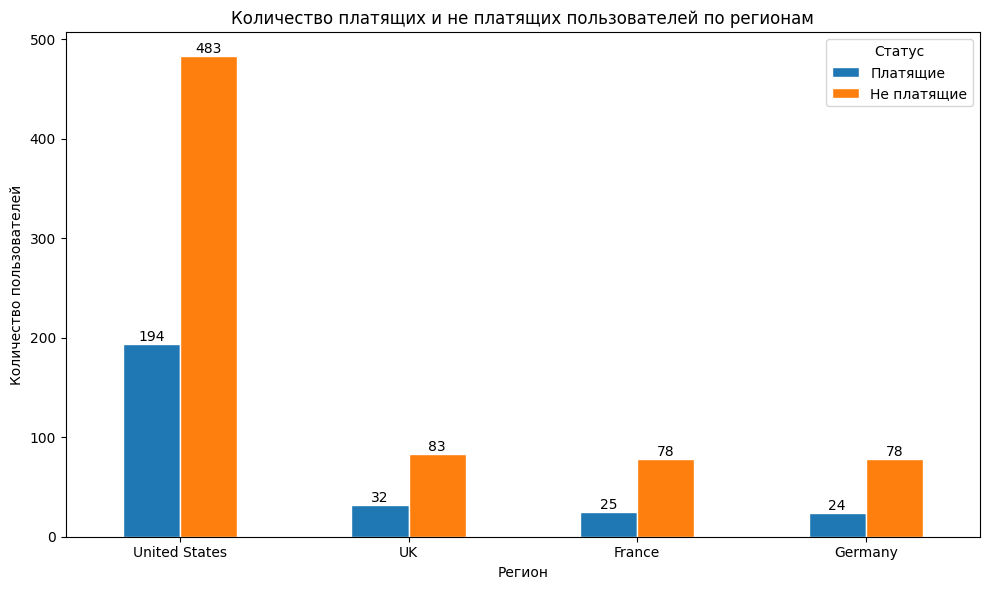

In [48]:
paying_region = ecom_df[ecom_df["payer"] == 1]["region"].value_counts()
non_paying_region = ecom_df[ecom_df["payer"] == 0]["region"].value_counts()

plot_grouped_bar(
    value_cols_dict={
        "Платящие": paying_region,
        "Не платящие": non_paying_region,
    },
    title="Количество платящих и не платящих пользователей по регионам",
    xlabel="Регион",
    ylabel="Количество пользователей",
)

Больше всего пользователей с United States.

Для дополнительного анализа и определения более выгодного региона для инвестиций, можно изучить конверсию по каждому региону.

#### Количество пользователей с разбивкой на платящих/не платящих по устройствам


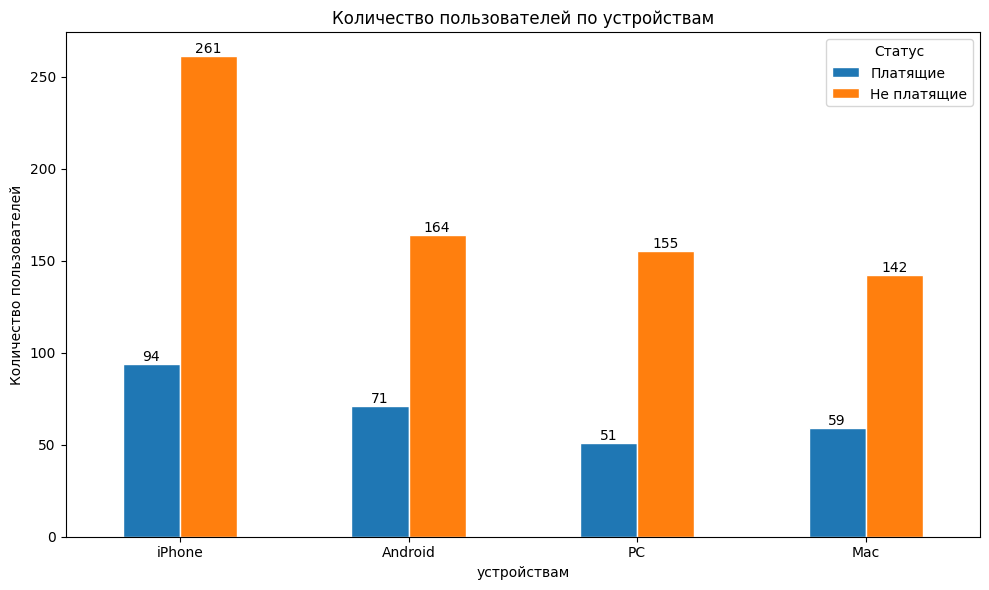

In [49]:
paying_device = ecom_df[ecom_df["payer"] == 1]["device"].value_counts()
non_paying_device = ecom_df[ecom_df["payer"] == 0]["device"].value_counts()

plot_grouped_bar(
    value_cols_dict={
        "Платящие": paying_device,
        "Не платящие": non_paying_device,
    },
    title="Количество пользователей по устройствам",
    xlabel="устройствам",
    ylabel="Количество пользователей",
)

График показывает соотношение платящих и не платящих пользователей по устройствам. Пользователи Mac покупают больше, чем PC, хотя их меньше. Аудитория Mac более платёжеспособна

#### Количество пользователей с разбивкой на платящих/не платящих по источникам


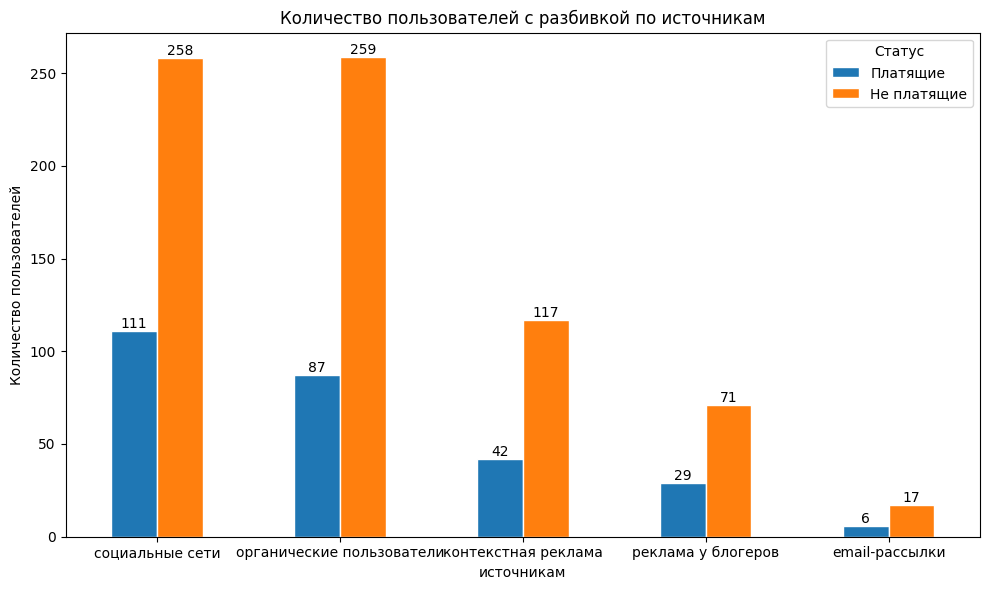

In [50]:
paying_channel = ecom_df[ecom_df["payer"] == 1]["channel"].value_counts()
non_paying_channel = ecom_df[ecom_df["payer"] == 0]["channel"].value_counts()

plot_grouped_bar(
    value_cols_dict={
        "Платящие": paying_channel,
        "Не платящие": non_paying_channel,
    },
    title="Количество пользователей с разбивкой по источникам",
    xlabel="источникам",
    ylabel="Количество пользователей",
)

Лидеры по трафику социальные сети и органические пользователи.  
Конверсия в покупку из социальных сетей больше, чем у органического трафика.  
Контекстная реклама, как самая дорогая, показывает плохую эффективность.  
email - приводит меньше всего пользователей

#### Графики, показывающие есть ли сезонность в продажах по месяцам, дням недели, времени суток


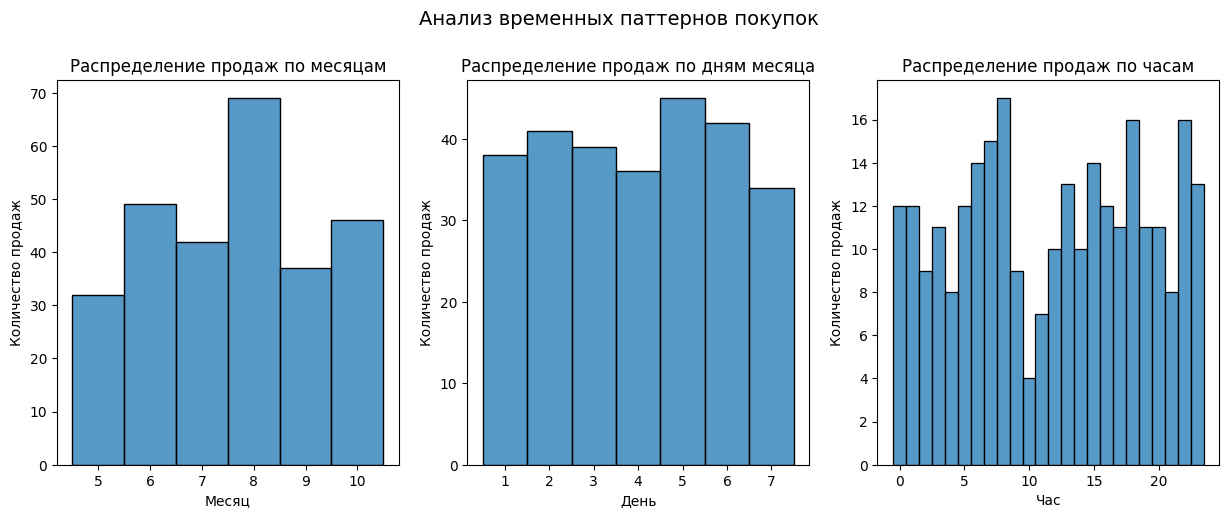

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Месяцы
sns.histplot(
    ecom_df[ecom_df["payer"] == 1], x="month", ax=axes[0], discrete=True
)
axes[0].set_title("Распределение продаж по месяцам")
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Количество продаж")

# Дни
sns.histplot(
    ecom_df[ecom_df["payer"] == 1], x="day", ax=axes[1], discrete=True
)
axes[1].set_title("Распределение продаж по дням месяца")
axes[1].set_xlabel("День")
axes[1].set_ylabel("Количество продаж")

# Часы
sns.histplot(
    ecom_df[ecom_df["payer"] == 1], x="hour_of_day", ax=axes[2], discrete=True
)
axes[2].set_title("Распределение продаж по часам")
axes[2].set_xlabel("Час")
axes[2].set_ylabel("Количество продаж")

fig.suptitle("Анализ временных паттернов покупок", fontsize=14, y=1.02)
plt.show()

По месяцам: больше всего продаж было в августе (~70), меньше всего — в мае (~30). В остальные месяцы примерно одинаково (~35).

По дням недели: продажи распределены примерно одинаково (~38), но больше всего — в пятницу и субботу, меньше всего — в воскресенье.

По времени суток: продажи начинают расти с 5 до 8 утра (в 8 утра — пик продаж), меньше всего покупают с 9 до 11 утра. Также есть заметные пики в 18 и 22 часа. В остальное время продажи находятся примерно на одном уровне.

#### Диаграмма количества покупок по типу оплаты


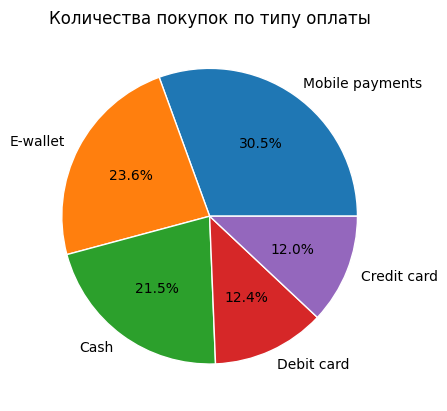

In [52]:
sales_payment_type = ecom_df[ecom_df["payer"] == 1][
    "payment_type"
].value_counts()
plot_pie(sales_payment_type, "Количества покупок по типу оплаты")

Большинство покупателей предпочитают Mobile payments (30.5%), E-wallet (23.6%) и Cash (21.5%).  
На дебетовые и кредитные карты суммарно приходится 24.4% платежей (дебетовые — 12.4%, кредитные — 12%).  
Доля безналичных платежей (Mobile payments + E-wallet + карты) составляет ~78%

Следует следить за удобством безналичной оплаты.

#### Количество пользователей привлеченных из каналов по регионам


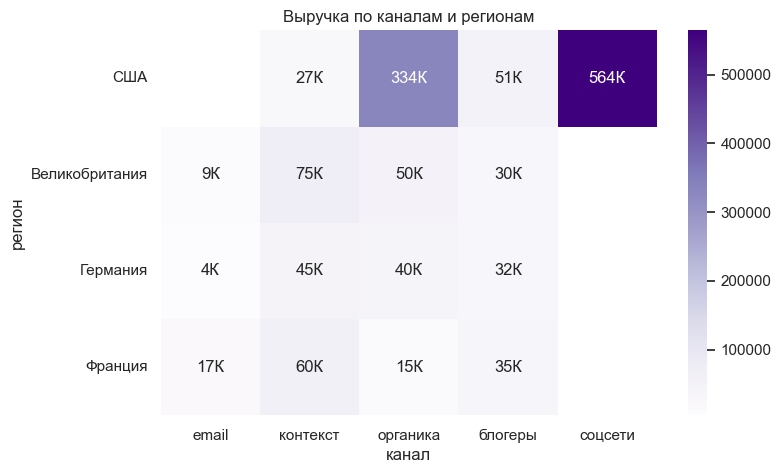

In [53]:
# Функция форматирования из тысяч в К
def format_k(x):
    if pd.isna(x):
        return ""
    if x >= 1_000_000:
        return f"{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"{int(x/1000)}К"
    else:
        return str(int(x))


#  порядок и названия
region_order = ["United States", "UK", "Germany", "France"]
region_names = ["США", "Великобритания", "Германия", "Франция"]

channel_order = [
    "email-рассылки",
    "контекстная реклама",
    "органические пользователи",
    "реклама у блогеров",
    "социальные сети",
]

channel_names = ["email", "контекст", "органика", "блогеры", "соцсети"]

pivot = ecom_df.pivot_table(
    values="total_amount", index="region", columns="channel", aggfunc="sum"
).reindex(index=region_order, columns=channel_order)

annot_data = pivot.copy()

for col in annot_data.columns:
    annot_data[col] = annot_data[col].map(format_k)

# стиль
sns.set_theme(style="white")

# график
fig, ax = plt.subplots(figsize=(8, 5))

sns.heatmap(pivot, annot=annot_data, fmt="", cmap="Purples", cbar=True, ax=ax)

ax.set_xticklabels(channel_names, rotation=0, ha="center")
ax.set_yticklabels(region_names, rotation=0, va="center")

ax.set_ylabel("регион")
ax.set_xlabel("канал")

# заголовок
ax.set_title("Выручка по каналам и регионам")

# прозрачный фон для фото презентации
fig.patch.set_alpha(0)

# сохранение для презентации
plt.savefig("heatmap.png", transparent=True, bbox_inches="tight")

plt.show()

Для регионов Европы нет данных по социальным сетям, самый эффективный канал — контекстная реклама. Однако для США самым эффективным каналом являются социальные сети. Учитывая успешность соцсетей в США, стоит протестировать канал и в Европе.

### Вывод по проделанному блоку "Исследовательский анализ данных" (только важное)

**Проделанные шаги:**

- очищены данные (стандартизация, удаление пропусков (1% данных), замена выбросов, исправление и удаление дубликатов (3 шт.), приведение типов столбцов к категориальному и дата-формату)
- определён исследуемый период (1 мая — 31 октября 2025 года)
- созданы новые столбцы: `total_amount` (итоговая сумма чека с учётом промокода), `payer` (флаг платящего пользователя), `time_of_day` (время суток)
- проведён анализ диаграмм

**Инсайты:**

- большая часть пользователей платит картами (70%)
- большинство покупок совершается с устройств Apple
- США — лидер по выручке, самый эффективный канал — социальные сети
- рекордная выручка зафиксирована в 8 месяце
- повторных продаж нет, средний чек равен стоимости одного товара (пользователь совершает одну покупку одного товара)

**Общий вывод:** пользователи преимущественно используют карты и устройства Apple, совершают разовые покупки без повторных продаж. Наибольшую выручку приносят США через социальные сети, пик продаж пришёлся на август.

## Проведение расчётов

### Средний чек


In [54]:
avg_check = ecom_df[ecom_df["payer"] == 1]["total_amount"].mean()
print(f"Средний чек - {round(avg_check, 2)}")

Средний чек - 5089.21


### Количество покупок на одного пользователя


In [55]:
# Количество уникальных платящих пользователей
unique_users = ecom_df[ecom_df["payer"] == 1].nunique()["user_id"]

# Количество покупок
all_bay = ecom_df["payer"].astype(int).sum()

aver_bay_one_user = all_bay / unique_users

print(f"В среднем один пользователь совершает {aver_bay_one_user} покупку")

В среднем один пользователь совершает 1.0 покупку


В среднем один пользователь совершает 1.0 покупку (Учитывая средний чек, каждый клиент приносит 5089 выручки). Повторных продаж нет — каждый платящий пользователь купил только один раз. Это говорит об отсутствии лояльности и повторных обращений. При высокой стоимости привлечения такая модель может быть нерентабельной в долгосрочной перспективе.

Также это подтверждает вывод пункта Аналитический и графический анализ

### Средняя продолжительность сессии по рекламным каналам.


In [56]:
duration_channel = (
    ecom_df.groupby("channel")["sessiondurationsec"]
    .mean()
    .round()
    .sort_values(ascending=False)
)

duration_channel

channel
контекстная реклама          1962.0
email-рассылки               1919.0
органические пользователи    1870.0
реклама у блогеров           1836.0
социальные сети              1692.0
Name: sessiondurationsec, dtype: float64

Самая долгая продолжительность сессии у пользователей из контекстной рекламы (32 мин), самая короткая — из социальных сетей (28 мин). Разница между каналами составляет
~4 минут.

### Средняя продолжительность сессии по типу устройства


In [57]:
duration_device = (
    ecom_df.groupby("device")["sessiondurationsec"]
    .mean()
    .round()
    .sort_values(ascending=False)
)
duration_device

device
PC         1931.0
Android    1901.0
Mac        1769.0
iPhone     1721.0
Name: sessiondurationsec, dtype: float64

Пользователи на PC проводят на сайте больше всего времени (32 мин), на iPhone — меньше всего (28 мин). Разница между устройствами составляет ~4 минуты. Возможно сайт написанный для устройств apple удобнее, что позволяет сделать процесс покупки быстрее и удобнее.

При этом доля покупателей на Mac и PC примерно одинаковая, несмотря на то, что на PC проводят больше времени. Значит сайт для Mac более клиентоориентирован: пользователи быстрее находят нужный товар и больше совершают покупку (это доказывалось на этапе построения графиков).

### Топ-3 рекламных канала по среднему чеку.


In [58]:
top_channels_avg = (
    ecom_df[ecom_df["payer"] == 1]
    .groupby("channel")["total_amount"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .head(3)
)
top_channels_avg

channel
email-рассылки        5332.37
реклама у блогеров    5199.01
социальные сети       5088.22
Name: total_amount, dtype: float64

Самый высокий средний чек приносят пользователи из email-рассылок (5332). email-рассылки и социальные сети показывают результат выше общего среднего чека. Несмотря на то, что email-рассылки привлекли меньше всего покупателей (2.2% от всех продаж), качество этих клиентов выше — они тратят больше.  
Остальные каналы показывают результат ниже среднего чека. Возможно, существует реферальная программа для привлечения органических пользователей.

### Топ-3 региона по среднему чеку.


In [59]:
top_regions_avg = (
    ecom_df[ecom_df["payer"] == 1]
    .groupby("region")["total_amount"]
    .mean()
    .round(2)
    .sort_values(ascending=False)
    .head(3)
)
top_regions_avg

region
France     5215.03
UK         5211.52
Germany    5136.53
Name: total_amount, dtype: float64

Самый высокий средний чек демонстрирует France (5215), незначительно опережая UK (5211) и Germany (5137). При этом United States, который лидирует по объему продаж (70% всех покупок), имеет средний чек ниже, чем другие регионы (около 5000).

### Топ-3 месяца по среднему чеку с разбивкой по регионам.


           region month  total_amount
1          France     6       5499.01
0          France     5       5224.05
5          France    10       5165.70
7         Germany     6       5679.02
10        Germany     9       5249.00
8         Germany     7       4999.00
12             UK     5       5499.00
17             UK    10       5341.87
13             UK     6       5270.46
21  United States     8       5152.22
20  United States     7       5051.97
22  United States     9       5049.03


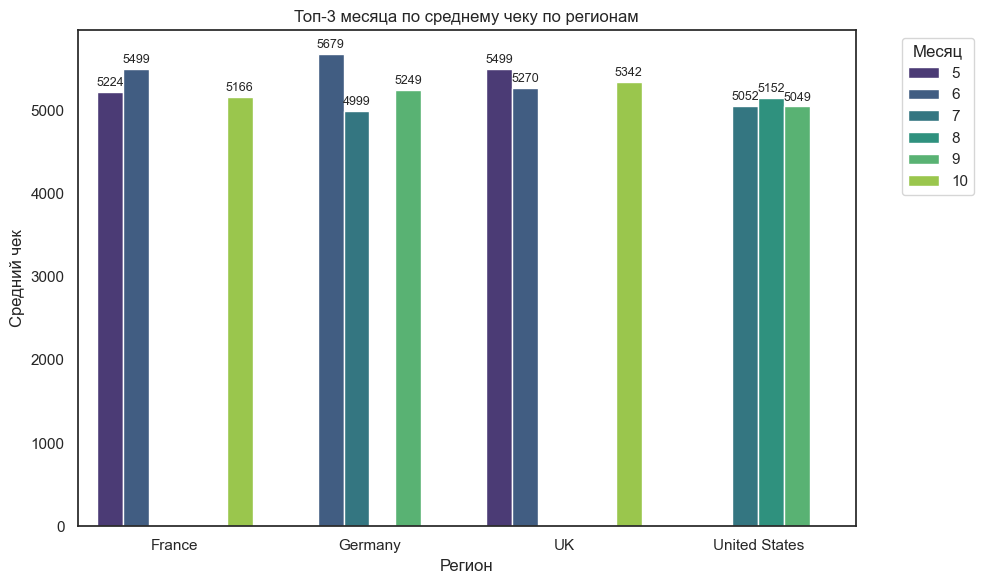

In [60]:
# Группировка данных по региону и месяцу по платящим пользователям
monthly_region_avg = (
    ecom_df[ecom_df["payer"] == 1]
    .groupby(["region", "month"])["total_amount"]
    .mean()
    .round(2)
    .reset_index()
)

# Отбор топ-3 месяцев по среднему чеку для каждого региона
top_months = (
    (
        monthly_region_avg.sort_values(
            ["region", "total_amount"], ascending=[True, False]
        )
    )
    .groupby("region")
    .head(3)
)

print(top_months)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_months,
    x="region",
    y="total_amount",
    hue="month",
    palette="viridis",
)

plt.title("Топ-3 месяца по среднему чеку по регионам")
plt.xlabel("Регион")
plt.ylabel("Средний чек")
plt.legend(title="Месяц", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=0)

# Добавление значений на столбцы
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt="%.0f", fontsize=9, padding=2)
plt.tight_layout()
plt.show()

Июнь — ключевой месяц с максимальными средними чеками в France (5499) и Germany (5679). США демонстрируют самые низкие чеки даже в топ-месяцах (5049-5152), ниже других показателей. France, Germany, UK регионы показывают более высокую платежеспособность клиентов.  
Прибыльные регионы подвержены сезонности с пиком в июне. США, напротив, более стабильна, но с более низкими средними чеками.

### MAU по каждому месяцу с разбивкой по рекламным каналам и топ-3 рекламных канала по количеству уникальных пользователей в месяц.


In [61]:
mau_pivot = ecom_df.pivot_table(
    index="month",
    columns="channel",
    values="user_id",
    aggfunc="nunique",
    fill_value=0,
)
# топ 3 рекламных канала по MAU
avg_mau = mau_pivot.mean().round(1).sort_values(ascending=False).head(3)
print(avg_mau, "\n")

# для дополнительной аналитики
mau_pivot

channel
социальные сети              61.5
органические пользователи    57.7
контекстная реклама          26.5
dtype: float64 



channel,email-рассылки,контекстная реклама,органические пользователи,реклама у блогеров,социальные сети
month,,,,,
5,7,8,76,14,41
6,1,28,59,13,53
7,3,24,46,15,56
8,4,35,60,20,68
9,2,38,58,20,66
10,6,26,47,18,85


Топ-3 рекламных канала по среднемесячному количеству уникальных пользователей:

Социальные сети — 61.5 пользователя в месяц
Органические пользователи — 57.7 пользователя в месяц
Контекстная реклама — 26.5 пользователя в месяц (без положительной динамики)
Динамика по месяцам:

Социальные сети — стабильный рост MAU (с 41 в мае до 85 в октябре)
Органический трафик — колеблется, пик в мае (76), снижение к октябрю (47)
Реклама у блогеров — показывает положительную динамику
Email-рассылки — не показывают увеличения активности

Социальные сети — самый перспективный канал для масштабирования, который показывает лидирующие показатели и рост. Органический трафик показывает стабильные показатели, но к октябрю немного снизился.

Email, контекстная и блогеры показывают стабильный результат или небольшой прирост.

### Таблица в которой будет указано по рекламным каналам: количество пользователей, количество уникальных пользователей, количество платящих пользователей, сумма продаж. И определить какой источник “принес” больше всего платящих пользователей и большую сумму продаж.

Также добавлен столбец с конверсией в процентах, чтобы определить, какой канал принес больше всего платящих пользователей в процентном соотношении.


In [62]:
channel_stats = (
    ecom_df.groupby("channel")
    .agg(
        количество_пользователей=("user_id", "count"),
        уникальных_пользователей=("user_id", "nunique"),
        платящих_пользователей=("payer", lambda x: (x == 1).sum()),
        сумма_продаж=("total_amount", "sum"),
    )
    .round(2)
    .sort_values("платящих_пользователей", ascending=False)
)

channel_stats["конверсия_%"] = (
    channel_stats["платящих_пользователей"]
    / channel_stats["количество_пользователей"]
    * 100
).round(1)


channel_stats

,количество_пользователей,уникальных_пользователей,платящих_пользователей,сумма_продаж,конверсия_%
channel,,,,,
социальные сети,369,369,111,564791.9,30.1
органические пользователи,346,346,87,441315.8,25.1
контекстная реклама,159,159,42,210659.6,26.4
реклама у блогеров,100,100,29,150771.4,29.0
email-рассылки,23,23,6,31994.2,26.1


Социальные сети — самый эффективный канал по всем метрикам: больше всего платящих пользователей (111), максимальная выручка (564791) и самая высокая конверсия (30%).

### Вывод по проделанному блоку "Проведение расчетов"

#### Ключевые инсайты

**Поведение пользователей:**

- Доказано, что повторных продаж нет, средний чек 5089.
- Самая долгая сессия у пользователей из контекстной рекламы (32 мин), самая короткая — из социальных сетей (28 мин).
- Пользователи на PC проводят на сайте больше времени (32 мин), на iPhone — меньше всего (28 мин). Доля клиентов на Mac и PC одинаковая, но покупателей на Mac больше, что говорит об удобстве сайта для устройств Apple.

**Регионы:**

- США — лидер по объёму продаж (70% всех покупок), но средний чек ниже Европейских регионов.
- France, UK, Germany — более платежеспособные клиенты (средний чек 5215, 5211 и 5137 соответственно).
- Июнь — пиковый месяц по средним чекам в Европе (до 5679). В США показатели стабильны, но ниже.

**Рекламные каналы:**

- Социальные сети — лучший канал по всем метрикам: 111 платящих пользователей, выручка 564 791, конверсия 30.1%, стабильный рост MAU.
- Email-рассылки — самый высокий средний чек (5332 руб.), но охват минимальный (2.2% от всех продаж).
- Органический трафик стабилен, но к октябрю наблюдается снижение.

#### Рекомендации

- **Отсутствие повторных продаж** — внедрить программу лояльности, кэшбэк, персональные скидки для повторных покупок.
- **Низкий средний чек в США** — увеличивать средний чек.
- **Сезонный пик в Европе (июнь)** — усилить маркетинговую активность перед июнем, подготовить специальные предложения.
- **Снижение органического трафика к октябрю** — проанализировать причины
- **Социальные сети — лучший канал** — масштабировать бюджет на соцсети регион США

## Проверка гипотез

Функция для проверки гипотезы и построения графика для визуализации


In [63]:
def test_hypothesis(groups, name):
    """
    Проверка статистических гипотез.

    Параметры:
    groups - список из 2 или более массивов данных
    name - название колонки
    """

    if len(groups) > 2:
        stat, p_value = kruskal(*groups)
        test_name = "Kruskal-Wallis"

    elif len(groups) == 2:
        stat, p_value = mannwhitneyu(groups[0], groups[1])
        test_name = "Mann-Whitney"

    else:
        print(f"{name}: недостаточно данных\n")
        return None

    print(
        f"{name}: метод {test_name},"
        f"p-value = {p_value:.4f}, stat = {stat:.4f}\n"
    )

    return p_value, test_name, stat


def plot_mean_median_boxplot(df, x_col, y_col, xlabel, ylabel, title):
    """
    Построение графика barplot (медианы и среднего значения) и boxplot

    Параметры:
    df - DataFrame
    x_col - номинальная колонка
    y_col - числовая колонка
    xlabel - подпись оси для x_col
    ylabel - подпись оси для y_col
    title - название показателя (например, 'чек', 'выручка')
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))

    # данные для barplot
    # средннее значение чека для региона
    mean_data = df.groupby(x_col)[y_col].mean().reset_index()
    mean_data["metric"] = "Средний"

    # медианное значение чека для региона
    median_data = df.groupby(x_col)[y_col].median().reset_index()
    median_data["metric"] = "Медианный"

    combined = pd.concat([mean_data, median_data])

    sns.barplot(data=combined, x=x_col, y=y_col, hue="metric", ax=axes[0])

    axes[0].set_title(f"Средний и медианный {title}")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)
    axes[0].legend(
        title="Показатель", bbox_to_anchor=(1.05, 1), loc="upper left"
    )

    # ящик с усами
    sns.boxplot(data=df, x=x_col, y=y_col, ax=axes[1])
    axes[1].set_title(f"Распределение {title}")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(ylabel)

    for ax in axes:
        ax.tick_params(axis="x", rotation=25)

    plt.tight_layout()
    plt.show()

### Влияет ли тип устройства на количество покупок в день по каждому региону?

**Формирование нулевой и альтернативной гипотезы**  
Нулевая гипотеза: Тип устройства не влияет на количество покупок в день в каждом регионе.  
Альтернативная гипотеза: Тип устройства влияет на количество покупок в день в каждом регионе.


In [64]:
# отбор только тех пользователей, которые совершили покупку
buyers = ecom_df[ecom_df["payer"] == 1].copy()

# колонка с днём для группировки
buyers["order_dt"] = buyers["order_dt"].dt.date

# группируем по устройству, региону и дню
grouped = (
    buyers.groupby(["device", "region", "order_dt"])
    .size()
    .reset_index(name="purchases_count")
)

# Проверяем гипотезу для каждого региона
for region, data in grouped.groupby("region"):

    # собираем данные по дням для каждого устройства
    groups = [
        group["purchases_count"].values for _, group in data.groupby("device")
    ]

    groups = [g for g in groups if len(np.unique(g)) > 1]

    test_hypothesis(groups, region)

France: недостаточно данных

Germany: недостаточно данных

UK: недостаточно данных

United States: метод Kruskal-Wallis,p-value = 0.3858, stat = 3.0383



Из-за отсутствия вариативности данных (максимум одна покупка в день на комбинацию устройство-регион) статистический тест применим только для US.

Результат (p-value = 0.3858) показывает, что тип устройства не влияет на количество покупок в день. Гипотеза не подтверждается.

### Влияет ли тип рекламного канала на количество покупок в день по каждому региону?

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: Тип рекламного канала не влияет на количество покупок в день, распределения количества покупок одинаковы для всех каналов.

Альтернативная гипотеза: Тип рекламного канала влияет на количество покупок в день, существует хотя бы один канал, который отличается от других.


In [65]:
group2 = (
    buyers.groupby(["channel", "region", "order_dt"])
    .size()
    .reset_index(name="purchases_count")
)

for region, data in group2.groupby("region"):
    groups = [
        group["purchases_count"].values for _, group in data.groupby("channel")
    ]

    test_hypothesis(groups, region)

France: метод Kruskal-Wallis,p-value = 0.4362, stat = 2.7238

Germany: метод Kruskal-Wallis,p-value = 0.8028, stat = 0.9937

UK: метод Kruskal-Wallis,p-value = 0.8060, stat = 0.9802

United States: метод Kruskal-Wallis,p-value = 0.1190, stat = 5.8528



Результаты проверки гипотез (p-value > 0.05 во всех регионах) показывают, что тип рекламного канала не оказывает статистически значимого влияния на количество покупок в день. Нулевая гипотеза не отвергается

### Проверить гипотезу о том, что средний чек отличается в зависимости от региона?

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: Средний чек не отличается в зависимости от региона, распределения среднего чека одинаковы для всех регионов.

Альтернативная гипотеза: Средний чек отличается в зависимости от региона, существует хотя бы один регион, который отличается по среднему чеку от других.


Средний чек от региона: метод Kruskal-Wallis,p-value = 0.2245, stat = 4.3662



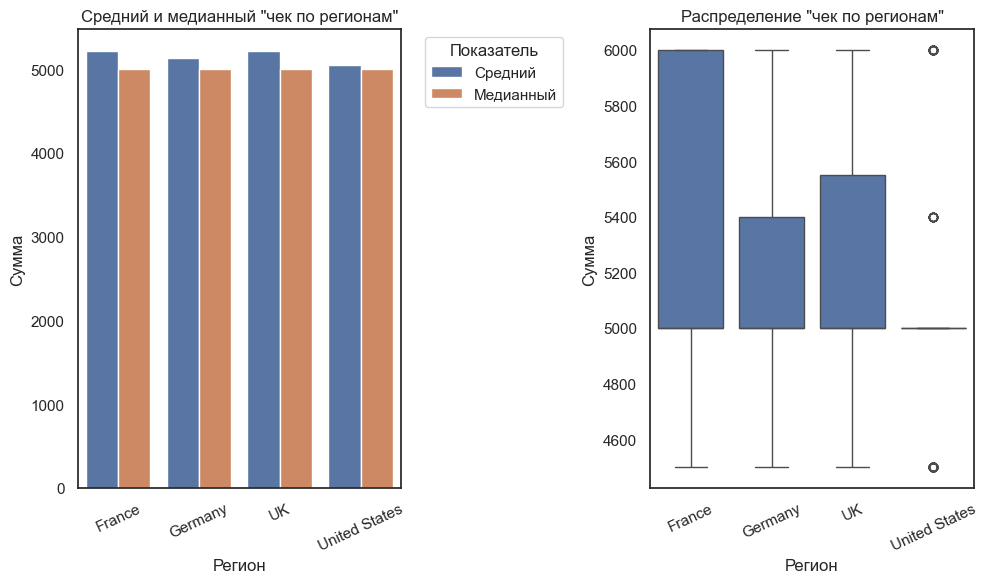

In [66]:
group3 = [
    group["total_amount"].values for _, group in buyers.groupby("region")
]
test_hypothesis(group3, "Средний чек от региона")

plot_mean_median_boxplot(
    buyers,
    x_col="region",
    y_col="total_amount",
    xlabel="Регион",
    ylabel="Сумма",
    title='"чек по регионам"',
)

Небольшие различия в средних значениях чеков между регионами, медианные значения практически совпадают, а распределения пересекаются

По результатам критерия Краскела–Уоллиса (p-value = 0.2245) статистически значимых различий не обнаружено.

Регион не оказывает значимого влияния на размер чека. Нулевая гипотеза не отвергается

### Проверить гипотезу о том, что средний чек отличается в зависимости от рекламного канала?

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: Средний чек не отличается в зависимости от рекламного канала. Распределения среднего чека одинаковы для всех рекламных каналов.

Альтернативная гипотеза: Средний чек отличается в зависимости от рекламного канала. Существует хотя бы один рекламный канал, который отличается по среднему чеку от других.


Средний чек от канала: метод Kruskal-Wallis,p-value = 0.3975, stat = 4.0634



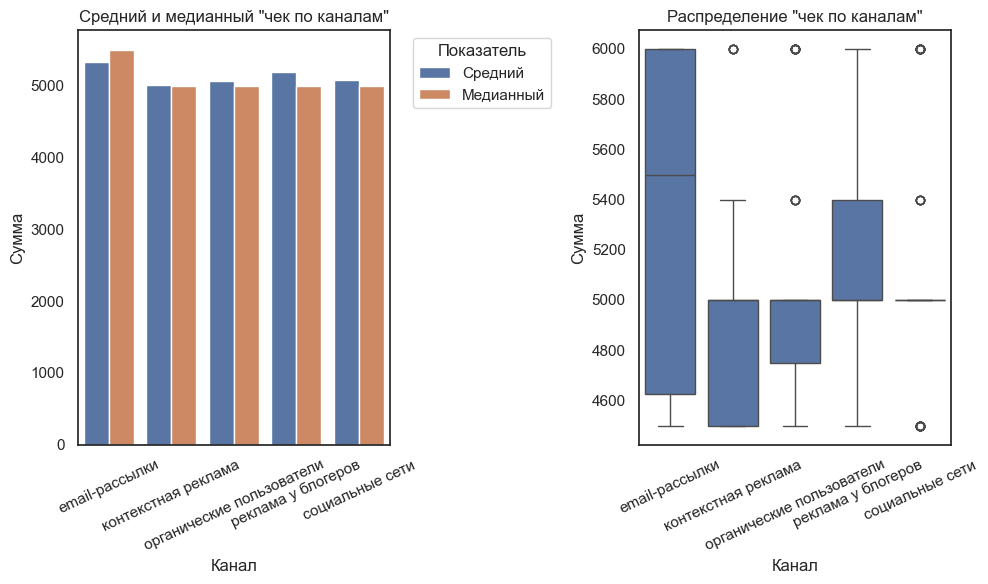

In [67]:
group4 = [
    group["total_amount"].values for _, group in buyers.groupby("channel")
]
test_hypothesis(group4, "Средний чек от канала")

plot_mean_median_boxplot(
    buyers,
    x_col="channel",
    y_col="total_amount",
    xlabel="Канал",
    ylabel="Сумма",
    title='"чек по каналам"',
)

Есть незначительные различия в средних значениях чеков по каналам, медианные значения практически совпадают, распределения пересекаются.

По результатам статистического теста Краскела–Уоллиса (p-value = 0.3975), значимых различий между каналами нет.

Рекламный канал не оказывает статистически значимого влияния на размер чека. Нулевая гипотеза не отвергается

### Проверить гипотезу о том, что средний чек отличается в зависимости от времени суток?

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: Средний чек не отличается в зависимости от времени суток. Распределения среднего чека одинаковы для всех временных периодов (утро, день, вечер, ночь).

Альтернативная гипотеза: Средний чек отличается в зависимости от времени суток. Существует хотя бы один временной период, который отличается по среднему чеку от других.


Средний чек от времени суток: метод Kruskal-Wallis,p-value = 0.3875, stat = 3.0271



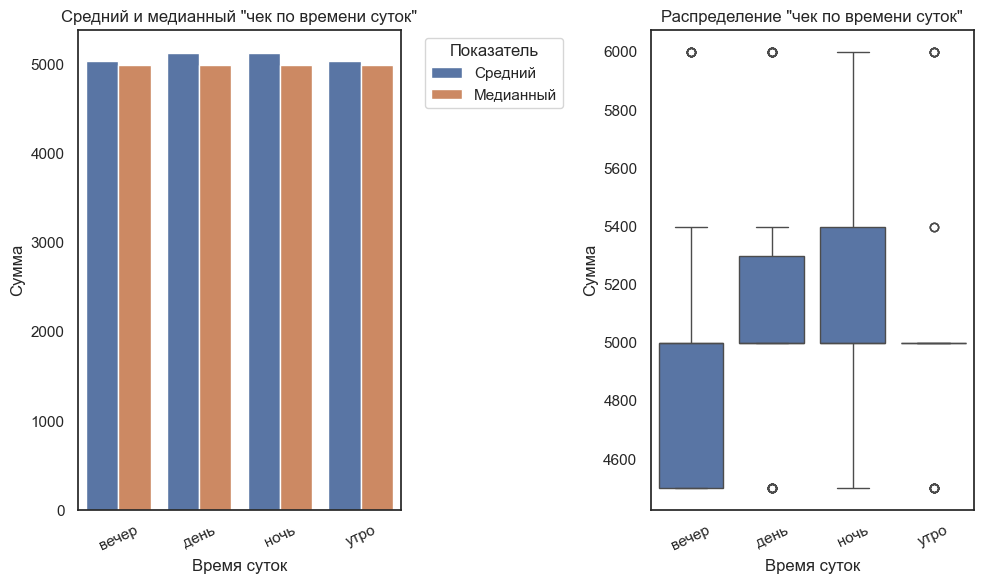

In [68]:
group5 = [
    group["total_amount"].values for _, group in buyers.groupby("time_of_day")
]
test_hypothesis(group5, "Средний чек от времени суток")

plot_mean_median_boxplot(
    buyers,
    x_col="time_of_day",
    y_col="total_amount",
    xlabel="Время суток",
    ylabel="Сумма",
    title='"чек по времени суток"',
)

Средние значения чеков по времени суток отличаются незначительно, при этом медианные значения совпадают.

По результатам статистического теста Краскела–Уоллиса (p-value = 0.3875) не выявлено значимых различий.

Время суток не оказывает статистически значимого влияния на размер чека. Нулевая гипотеза не отвергается

### Есть ли взаимосвязь между продолжительностью сессии с суммой покупок?

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: Продолжительность сессии и сумма покупок не связаны между собой. Корреляция между этими переменными равна нулю.

Альтернативная гипотеза: Продолжительность сессии и сумма покупок имеют взаимосвязь. Корреляция между этими переменными статистически значимо отличается от нуля.


Коэффициент корреляции Спирмена: -0.0014, p-value: 0.9811


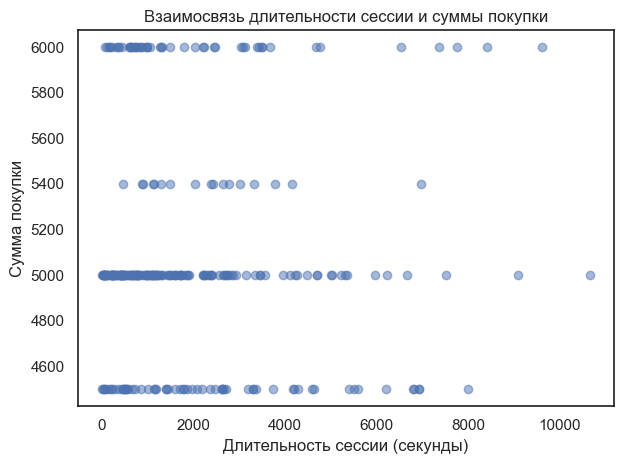

In [69]:
corr, p_value = spearmanr(buyers["sessiondurationsec"], buyers["total_amount"])

print(f"Коэффициент корреляции Спирмена: {corr:.4f}, p-value: {p_value:.4f}")

plt.scatter(buyers["sessiondurationsec"], buyers["total_amount"], alpha=0.5)
plt.title("Взаимосвязь длительности сессии и суммы покупки", fontsize=12)
plt.xlabel("Длительность сессии (секунды)")
plt.ylabel("Сумма покупки")
plt.tight_layout()
plt.show()

Для оценки взаимосвязи между длительностью сессии и суммой покупки был использован коэффициент корреляции Спирмена.

Полученное значение коэффициента близко к нулю (-0.001), p-value = 0.98, что говорит об отсутствии статистически значимой связи.

Визуальный анализ (scatter plot) также не выявил зависимости между переменными.

Длительность сессии не связана с суммой покупки. Нулевая гипотеза не отвергается

### Влияет ли день недели на средний чек (дополнительная гипотеза)

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: День недели не влияет на средний чек. Распределения среднего чека одинаковы для всех дней недели.

Альтернативная гипотеза: День недели влияет на средний чек. Существует хотя бы один день недели, который отличается по среднему чеку от других.


Средний чек от дня недели: метод Kruskal-Wallis,p-value = 0.6604, stat = 4.1201



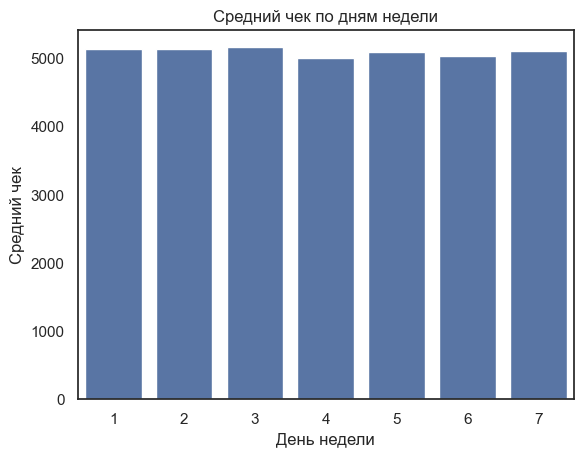

In [70]:
day_groups = []

for day in sorted(buyers["day"].unique()):
    day = buyers[buyers["day"] == day]["total_amount"].values
    day_groups.append(day)

test_hypothesis(day_groups, "Средний чек от дня недели")

ax = sns.barplot(
    data=buyers,
    x="day",
    y="total_amount",
    estimator="mean",
    errorbar=None,
)

plt.title("Средний чек по дням недели")
plt.xlabel("День недели")
plt.ylabel("Средний чек")
plt.show()

день не зависит от чека. Нулевая гипотеза не отвергается

### Влияет ли наличие промокода на сумму покупки (дополнительная гипотеза)

**Формирование нулевой и альтернативной гипотезы**

Нулевая гипотеза: Наличие промокода не влияет на сумму покупки.

Альтернативная гипотеза: Наличие промокода влияет на сумму покупки.


In [71]:
# группа с промокодом и без
group_promo_1 = buyers[buyers["promo_code"] == 1]["total_amount"]
group_promo_0 = buyers[buyers["promo_code"] == 0]["total_amount"]

print(f"p-value: {mannwhitneyu(group_promo_0, group_promo_1)[1]:.4f}")

print(f"Средний чек без промокода: {group_promo_0.mean():.0f}")
print(f"Средний чек с промокодом: {group_promo_1.mean():.0f}")

diff = group_promo_0.mean() - group_promo_1.mean()
percent = (diff / group_promo_0.mean()) * 100
print(f"Разница: {diff:.0f} ({percent:.1f}%)")

p-value: 0.0000
Средний чек без промокода: 5249
Средний чек с промокодом: 4693
Разница: 556 (10.6%)


Промокод влияет на сумму покупки. Нулевая гипотеза отвергается

### Вывод по проделанному блоку "Проверка гипотез"

Из всех проверенных факторов только промокод влияет на сумму покупки. Остальные гипотезы не подтвердились.

#### Инсайты

- Тип устройства, рекламный канал, регион, время суток, день недели не влияют на покупки и средний чек.
- Длительность сессии не связана с суммой покупки (корреляция почти нулевая).
- По регионам (кроме US) нет вариативности данных — максимум одна покупка в день.
- Промокод — единственный рабочий фактор.

#### Рекомендации по улучшениям

- Промокоды основной инструмент маркетинга.

## Регрессионное моделирование

Предсказывать буду стоимость чека.

Создание тепловой карты корреляции, чтобы учесть, какие факторы стоит включить в модель


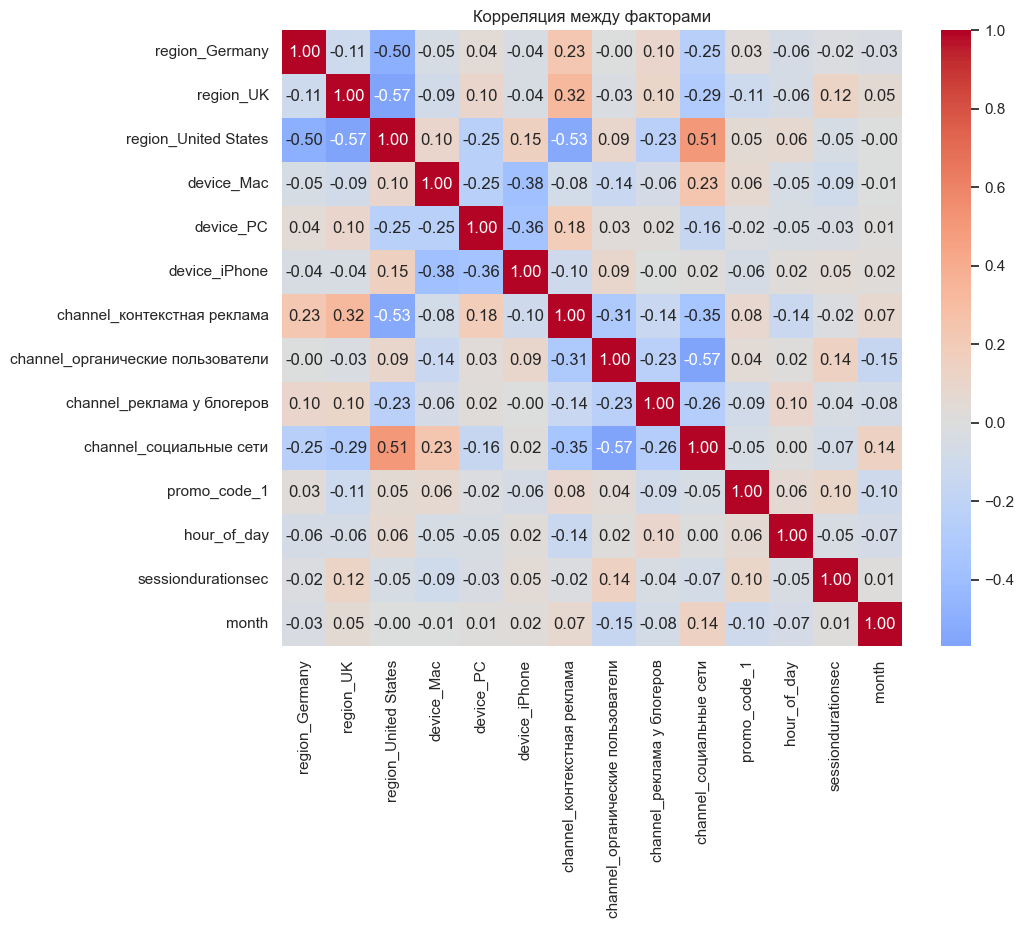

total_amount                         1.000000
region_UK                            0.137837
sessiondurationsec                   0.036034
channel_реклама у блогеров           0.032556
hour_of_day                          0.031361
channel_социальные сети              0.029050
month                               -0.002805
device_PC                           -0.013995
device_iPhone                       -0.016291
channel_органические пользователи   -0.016468
device_Mac                          -0.037334
region_Germany                      -0.040390
channel_контекстная реклама         -0.073806
region_United States                -0.121401
promo_code_1                        -0.510019
Name: total_amount, dtype: float64


In [72]:
# столбцы для предсказания модели
features = [
    "region",
    "device",
    "channel",
    "promo_code",
    "hour_of_day",
    "month",
    "sessiondurationsec",
]
# разделение колонок на категориальные и количественные
cat_feature = ["region", "device", "channel", "promo_code"]
num_feature = ["hour_of_day", "sessiondurationsec", "month"]

# факторы
x = buyers[features]
y = buyers["total_amount"]

# тренировочная и тестовая выборка (размер тестовой выборки 15%)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.15, random_state=42
)

# кодирование категориальных признаков
encoder = OneHotEncoder(
    sparse_output=False, handle_unknown="ignore", drop="first"
)
x_train_cat = encoder.fit_transform(x_train[cat_feature])
x_test_cat = encoder.transform(x_test[cat_feature])

# создание DataFrame для дальнейшей работы с категориальными факторами
x_train_cat_df = pd.DataFrame(
    x_train_cat, columns=encoder.get_feature_names_out(), index=x_train.index
)

x_test_cat_df = pd.DataFrame(
    x_test_cat, columns=encoder.get_feature_names_out(), index=x_test.index
)

# объединяем все факторы
x_train_res = pd.concat([x_train_cat_df, x_train[num_feature]], axis=1)
x_test_res = pd.concat([x_test_cat_df, x_test[num_feature]], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(
    x_train_res.corr(),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
)
plt.title("Корреляция между факторами")
plt.show()

corr_with_target = (
    x_train_res.join(y_train)
    .corr()["total_amount"]
    .sort_values(ascending=False)
)
print(corr_with_target)

Мультиколлинеарности - нет (все факторы оставляю). Признаки (регион, устройство, канал, время суток, месяц, длительность сессии) практически не влияют на сумму покупки. Сумма покупки сильно зависит от применения промокода. Проверим модель учитывая слабые факторы и не учитывая.


In [73]:
# обучаем модель
model = LinearRegression()
model.fit(x_train_res, y_train)

y_pred = model.predict(x_test_res)

mae = mean_absolute_error(y_test, y_pred)

print(
    f"MAE: {mae} или"
    f"{round(mae / ecom_df['total_amount'].mean() * 100, 2)}% от среднего"
)
print("R2:", r2_score(y_test, y_pred))

MAE: 402.3565382490998 или7.91% от среднего
R2: 0.2389214049912578


Модель объясняет около 24% вариации целевой переменной, что указывает на наличие сложных нелинейных зависимостей или отсутствующих факторов.


In [74]:
tabl_for_an_features = pd.DataFrame(
    {"Фактор": x_train_res.columns, "Влияние фактора": model.coef_}
)

tabl_for_an_features["Абсолютный коэффициент"] = tabl_for_an_features[
    "Влияние фактора"
].abs()
tabl_for_an_features = tabl_for_an_features.sort_values(
    by="Абсолютный коэффициент", ascending=False
)
print(tabl_for_an_features)

                               Фактор  Влияние фактора  Абсолютный коэффициент
10                       promo_code_1      -530.186546              530.186546
2                region_United States      -308.390403              308.390403
0                      region_Germany      -213.469435              213.469435
6         channel_контекстная реклама      -210.950211              210.950211
8          channel_реклама у блогеров      -175.411789              175.411789
4                           device_PC      -112.611423              112.611423
5                       device_iPhone       -78.947888               78.947888
3                          device_Mac       -71.530235               71.530235
7   channel_органические пользователи       -65.629524               65.629524
1                           region_UK       -65.050446               65.050446
13                              month       -17.750890               17.750890
11                        hour_of_day         3.5686

Наиболее значимым фактором оказался признак использования промокода, снижающий сумму заказа в среднем на 530 единиц. Также существенное влияние оказывают регион и канал привлечения пользователя. В то же время такие признаки, как длительность сессии и время суток, оказывают минимальное влияние на целевую переменную.


In [75]:
features_to_drop = [
    "sessiondurationsec",
    "channel_социальные сети",
    "hour_of_day",
]

x_train_new = x_train_res.drop(columns=features_to_drop)
x_test_new = x_test_res.drop(columns=features_to_drop)

model.fit(x_train_new, y_train)
y_pred_new = model.predict(x_test_new)

print("R2:", r2_score(y_test, y_pred_new))

R2: 0.2124296878280375


Несмотря на низкую индивидуальную значимость некоторых признаков, их удаление привело к ухудшению качества модели, что указывает на наличие скрытых зависимостей.

Верну признаки и попробуем прологарифмировать


MAE: 394.1276582404196
R2: 0.2430788105928503


Text(0.5, 1.0, 'Качество модели')

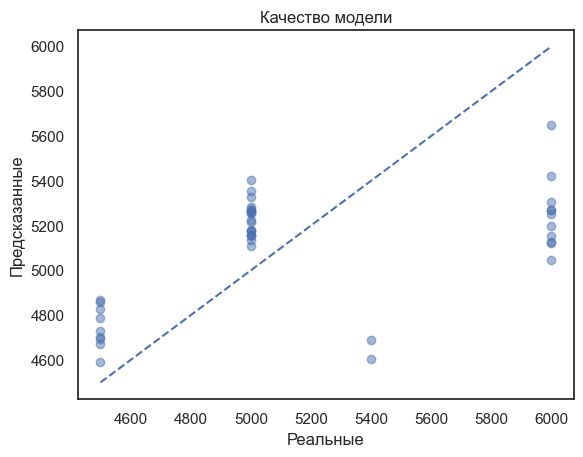

In [76]:
# логарифмируем
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# обучение модель
model = LinearRegression()
model.fit(x_train_res, y_train_log)

# Предсказание и возвращение к исходному масштабу
y_pred_log = model.predict(x_test_res)
y_pred = np.expm1(y_pred_log)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

# Визуализация модели
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--"
)

plt.xlabel("Реальные")
plt.ylabel("Предсказанные")
plt.title("Качество модели")

- Логарифмирование: применение логарифмической трансформации целевой переменной позволило немного улучшить качество модели: средняя абсолютная ошибка снизилась с 402 до 394, а коэффициент детерминации увеличился с 0.239 до 0.242.
  Это подтверждает, что в данных присутствуют выбросы и асимметрия распределения, однако линейная модель по-прежнему ограничена в способности описывать сложные зависимости.

- График: модель склонна недооценивать большие значения и переоценивать малые, что указывает на её стремление к среднему значению и недостаточную способность учитывать экстремальные значения.

В ходе работы была построена модель линейной регрессии для предсказания суммы заказа на основе факторов поведения пользователя источников привлечения.
Наиболее значимым фактором оказался признак использования промокода, который снижает сумму заказа в среднем на 530 единиц. Также заметное влияние оказывают регион пользователя и канал привлечения.
При этом большинство признаков показали слабую линейную зависимость с целевой переменной, что подтверждается низким значением коэффициента детерминации (R² ≈ 0.24). Это указывает на наличие сложных или нелинейных зависимостей в данных.
Средняя абсолютная ошибка модели составила около 402 единиц, что соответствует примерно 8% от среднего чека (5082).

Возможные способы улучшения модели:

- Использование нелинейных моделей - Линейная регрессия не учитывает сложные зависимости между признаками (как в нашем случае). Применение моделей, таких как случайный лес или градиентный бустинг, может значительно повысить точность предсказаний.

Расширение набора данных
Добавление новых факторов (например, информация о пользователе, категории товаров или истории покупок) может существенно улучшить качество модели.
